<a href="https://colab.research.google.com/github/nickocruzm/CS260-Project/blob/main/Nickos_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
"""
Baseline vs. engineered-feature comparison for fake/real news classification.

Experimental design:
  - ONE locked train/test split, reused across every experiment.
  - ONE fixed model + metric harness, so the ONLY thing that changes between
    runs is the feature set.
  - Three contestants:
        1. TF-IDF (cleaned)    (the baseline to beat)
        2. Engineered features
        3. TF-IDF + engineered
  - Cross-validated scores with standard deviation, because a single AUC
    number is noise, not a result.

Fill in the DATA LOADING section with your own dataframe, then run.
"""

import re
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction import text as sk_text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb


# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.30
MAX_FEATURES = 5000
CV_FOLDS = 5

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.1,
    "eval_metric": "auc",
    "tree_method": "hist",   # required for GPU; also the fast modern CPU method
    "device": "cuda",        # run training on GPU (XGBoost >= 2.0 syntax)
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

# Source/dateline tokens to strip so the model can't cheat on outlet identity.
# Expand this as feature inspection reveals new artifacts.
LEAK_TERMS = {
    "reuters", "reuter", "ap", "afp", "bloomberg", "cnn", "fox",
    "breitbart", "getty", "npr", "newsletter", "subscribe", "featured",
    "pic", "via", "twitter", "photo",
}
CUSTOM_STOP = list(sk_text.ENGLISH_STOP_WORDS.union(LEAK_TERMS))



## Function Defniitions

In [ ]:
# ----------------------------------------------------------------------------
# DATA LOADING
# ----------------------------------------------------------------------------
def load_data():
    """
    Return (texts, labels) where:
      texts  : pandas Series of raw article strings
      labels : pandas Series of 0/1 labels (1 = real, 0 = fake, or your choice)

    Replace the body below with however you load your data, e.g.:
        df = pd.read_csv("news.csv")
        return df["text"], df["label"]
    """
    df = pd.read_csv(f"{path}/WELFake_Dataset.csv")
    df.drop('Unnamed: 0', axis=1, inplace=True)
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
    df['full_text'] = df['title'] + ' ' + df['text']
    return df['full_text'], df['label']



# ----------------------------------------------------------------------------
# LEAKAGE CLEANING
# ----------------------------------------------------------------------------
def strip_dateline(text_str):
    """Remove 'CITY (Source) - ' style datelines and residual source parentheticals."""
    if not isinstance(text_str, str):
        return ""
    # Leading "WASHINGTON (Reuters) - " style prefix
    text_str = re.sub(r"^[A-Z][A-Za-z.\s/]+\([^)]*\)\s*[-\u2013\u2014]\s*", "", text_str)
    # Any remaining "(Reuters)" / "(AP)" style parentheticals
    text_str = re.sub(
        r"\([^)]*(reuters|reuter|ap|afp|bloomberg)[^)]*\)",
        "",
        text_str,
        flags=re.IGNORECASE,
    )
    return text_str


# ----------------------------------------------------------------------------
# ENGINEERED FEATURES  (source-independent stylometrics)
# ----------------------------------------------------------------------------

# Stylometrics (or stylometry) is the statistical and computational study of linguistic style.

def extract_features(text_str):
    """Turn one article into a dict of style/structure features."""
    if not isinstance(text_str, str):
        text_str = ""
    words = text_str.split()
    sentences = [s for s in re.split(r"[.!?]+", text_str) if s.strip()]
    n_words = len(words) or 1
    n_sents = len(sentences) or 1
    n_chars = len(text_str) or 1

    # Features

    return {
        "n_words": len(words),
        "n_sentences": len(sentences),
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0.0,
        "avg_sent_len": n_words / n_sents,
        "exclaim_rate": text_str.count("!") / n_words,
        "question_rate": text_str.count("?") / n_words,
        "quote_rate": text_str.count('"') / n_words,
        "caps_word_rate": sum(w.isupper() and len(w) > 1 for w in words) / n_words,
        "digit_rate": sum(c.isdigit() for c in text_str) / n_chars,
        "type_token_ratio": len(set(w.lower() for w in words)) / n_words,
    }


def build_feature_frame(texts):
    """Vectorized application of extract_features over a text Series."""
    return texts.apply(lambda t: pd.Series(extract_features(t)))


# ----------------------------------------------------------------------------
# EVALUATION HARNESS  (identical for every feature set)
# ----------------------------------------------------------------------------
def make_model():
    return xgb.XGBClassifier(**XGB_PARAMS)


def evaluate(X_train, X_test, y_train, y_test, label, results):
    """Train once on the locked split, score AUC on the held-out test set."""
    model = make_model()
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    preds = model.predict(X_test)

    print(f"\n{'=' * 60}")
    print(f"  {label}")
    print(f"{'=' * 60}")
    print(f"  Held-out AUC: {auc:.4f}")
    print("  Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print("  Classification report:")
    print(classification_report(y_test, preds, digits=3))

    results.append({"experiment": label, "holdout_auc": auc, "model": model})
    return model


def cross_validate(X, y, label, results_cv):
    """Cross-validated AUC with spread, so we can tell signal from noise."""
    scores = cross_val_score(
        make_model(), X, y, cv=CV_FOLDS, scoring="roc_auc", n_jobs=-1
    )
    print(f"  {label:28s} CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}")
    results_cv.append(
        {"experiment": label, "cv_mean": scores.mean(), "cv_std": scores.std()}
    )



# Pre-Processing Data

## Cleaning Data

In [ ]:

texts, labels = load_data()
texts = texts.reset_index(drop=True)
labels = labels.reset_index(drop=True)
print(f"Loaded {len(texts)} articles.")
print("Class balance:")
print(labels.value_counts(normalize=True).round(3).to_string())
text_clean = texts.apply(strip_dateline)

Loaded 63121 articles.
Class balance:
label
0    0.551
1    0.449


## Splitting Data into Train and Test sets

In [ ]:
# lock the split ONCE on raw indices
train_idx, test_idx = train_test_split(
    np.arange(len(texts)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)
y_train = labels.iloc[train_idx]
y_test = labels.iloc[test_idx]
print(f"\nTrain: {len(train_idx)}  Test: {len(test_idx)}")
print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  balance:", y_test.value_counts(normalize=True).round(3).to_dict())

holdout_results = []
cv_results = []

# XGBoost Models

## Baseline
- Used TF-IDF Vectorizer and evaluated model

In [ ]:
# --- 1. BASELINE: TF-IDF (cleaned) --------------------------------------
vec = TfidfVectorizer(max_features=MAX_FEATURES, stop_words=CUSTOM_STOP)
Xtrain_tfidf = vec.fit_transform(text_clean.iloc[train_idx])
Xtest_tfidf = vec.transform(text_clean.iloc[test_idx])
evaluate(Xtrain_tfidf, Xtest_tfidf, y_train, y_test,
            "BASELINE: TF-IDF (cleaned)", holdout_results)


  BASELINE: TF-IDF (cleaned)
  Held-out AUC: 0.6163
  Confusion matrix:
[[9630  808]
 [6134 2365]]
  Classification report:
              precision    recall  f1-score   support

           0      0.611     0.923     0.735     10438
           1      0.745     0.278     0.405      8499

    accuracy                          0.633     18937
   macro avg      0.678     0.600     0.570     18937
weighted avg      0.671     0.633     0.587     18937



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## Challenger
- Model incorporates the engineered features (without TF-IDF)

In [ ]:
# --- 2. CHALLENGER: engineered features ---------------------------------
feature_df = build_feature_frame(text_clean)
Xtrain_eng = feature_df.iloc[train_idx].values
Xtest_eng = feature_df.iloc[test_idx].values
eng_model = evaluate(Xtrain_eng, Xtest_eng, y_train, y_test,
                        "CHALLENGER: Engineered features", holdout_results)


  CHALLENGER: Engineered features
  Held-out AUC: 0.8893
  Confusion matrix:
[[8988 1450]
 [2096 6403]]
  Classification report:
              precision    recall  f1-score   support

           0      0.811     0.861     0.835     10438
           1      0.815     0.753     0.783      8499

    accuracy                          0.813     18937
   macro avg      0.813     0.807     0.809     18937
weighted avg      0.813     0.813     0.812     18937



## Combined TF-IDF + Engineered

- Model combines the engineered features withe TF-IDF

In [ ]:
# --- 3. COMBINED: TF-IDF + engineered -----------------------------------
Xtrain_comb = hstack([Xtrain_tfidf, csr_matrix(Xtrain_eng)])
Xtest_comb = hstack([Xtest_tfidf, csr_matrix(Xtest_eng)])
evaluate(Xtrain_comb, Xtest_comb, y_train, y_test,
            "COMBINED: TF-IDF + engineered", holdout_results)


  COMBINED: TF-IDF + engineered
  Held-out AUC: 0.7683
  Confusion matrix:
[[7964 2474]
 [1980 6519]]
  Classification report:
              precision    recall  f1-score   support

           0      0.801     0.763     0.781     10438
           1      0.725     0.767     0.745      8499

    accuracy                          0.765     18937
   macro avg      0.763     0.765     0.763     18937
weighted avg      0.767     0.765     0.765     18937



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

# Evaluation

In [ ]:
# --- cross-validation (signal vs. noise check) --------------------------
print(f"\n{'=' * 60}")
print("  CROSS-VALIDATED AUC  (mean +/- std over folds)")
print(f"{'=' * 60}")
# Rebuild full-data matrices for CV (vectorizer refit inside each fold would
# be ideal via a Pipeline; here we use a single fit for a quick variance read).
X_tfidf_all = vec.fit_transform(text_clean)
X_eng_all = feature_df.values
X_comb_all = hstack([X_tfidf_all, csr_matrix(X_eng_all)])
cross_validate(X_tfidf_all, labels, "TF-IDF (cleaned)", cv_results)
cross_validate(X_eng_all, labels, "Engineered", cv_results)
cross_validate(X_comb_all, labels, "TF-IDF + engineered", cv_results)


  CROSS-VALIDATED AUC  (mean +/- std over folds)
  TF-IDF (cleaned)             CV AUC: 0.6544 +/- 0.0543
  Engineered                   CV AUC: 0.8904 +/- 0.0006
  TF-IDF + engineered          CV AUC: 0.6676 +/- 0.0898


In [ ]:
# --- engineered feature directions (interpretability payoff) ------------
print(f"\n{'=' * 60}")
print("  ENGINEERED FEATURE DIRECTIONS  (train set per-class means)")
print(f"{'=' * 60}")
classes = sorted(labels.unique())
train_feats = feature_df.iloc[train_idx]
header = f"  {'feature':18s}" + "".join(f"  class={c}" for c in classes)
print(header)
for col in feature_df.columns:
    means = [train_feats[y_train.values == c][col].mean() for c in classes]
    row = f"  {col:18s}" + "".join(f"  {m:9.3f}" for m in means)
    print(row)


  ENGINEERED FEATURE DIRECTIONS  (train set per-class means)
  feature             class=0  class=1
  n_words               583.281    521.613
  n_sentences            33.945     28.037
  avg_word_len            5.098      5.075
  avg_sent_len           19.242     19.448
  exclaim_rate            0.000      0.004
  question_rate           0.001      0.003
  quote_rate              0.001      0.001
  caps_word_rate          0.015      0.033
  digit_rate              0.006      0.007
  type_token_ratio        0.588      0.604


In [ ]:

importances = eng_model.feature_importances_
print("\n  Engineered feature importances (challenger model):")
order = np.argsort(importances)[::-1]
for i in order:
    print(f"    {feature_df.columns[i]:18s} {importances[i]:.3f}")


  Engineered feature importances (challenger model):
    exclaim_rate       0.349
    question_rate      0.207
    n_sentences        0.085
    caps_word_rate     0.063
    quote_rate         0.063
    n_words            0.059
    avg_sent_len       0.051
    avg_word_len       0.049
    digit_rate         0.041
    type_token_ratio   0.034


In [ ]:
# --- final comparison table ---------------------------------------------
print(f"\n{'=' * 60}")
print("  SUMMARY  (did the challenger beat the baseline?)")
print(f"{'=' * 60}")
summary = pd.DataFrame(
    [{"experiment": r["experiment"], "holdout_auc": round(r["holdout_auc"], 4)}
        for r in holdout_results]
).merge(
    pd.DataFrame(cv_results).assign(
        cv=lambda d: d["cv_mean"].round(4).astype(str)
        + " +/- " + d["cv_std"].round(4).astype(str)
    )[["experiment", "cv"]],
    on="experiment", how="left",
)
print(summary.to_string(index=False))

baseline_auc = holdout_results[0]["holdout_auc"]
print(f"\n  Baseline (TF-IDF) held-out AUC: {baseline_auc:.4f}")
for r in holdout_results[1:]:
    delta = r["holdout_auc"] - baseline_auc
    verdict = "BEATS baseline" if delta > 0 else "below baseline"
    print(f"  {r['experiment']:35s} {delta:+.4f}  ({verdict})")
print("\n  NOTE: a difference smaller than the CV std is noise, not a win.")


  SUMMARY  (did the challenger beat the baseline?)
                     experiment  holdout_auc  cv
     BASELINE: TF-IDF (cleaned)       0.6163 NaN
CHALLENGER: Engineered features       0.8893 NaN
  COMBINED: TF-IDF + engineered       0.7683 NaN

  Baseline (TF-IDF) held-out AUC: 0.6163
  CHALLENGER: Engineered features     +0.2730  (BEATS baseline)
  COMBINED: TF-IDF + engineered       +0.1521  (BEATS baseline)

  NOTE: a difference smaller than the CV std is noise, not a win.


#### evaluation metric: AUC

AUC is the probability that, if you pick one real article and one fake article at random, your model assigns a higher "real" score to the actual real one

```
AUC = 1.0 — perfect ranking; every random real article is scored higher than every fake one. Perfect Seperation.
AUC = 0.5 — no better than random guessing (the diagonal line on the plot).
AUC < 0.5 — worse than random.
```


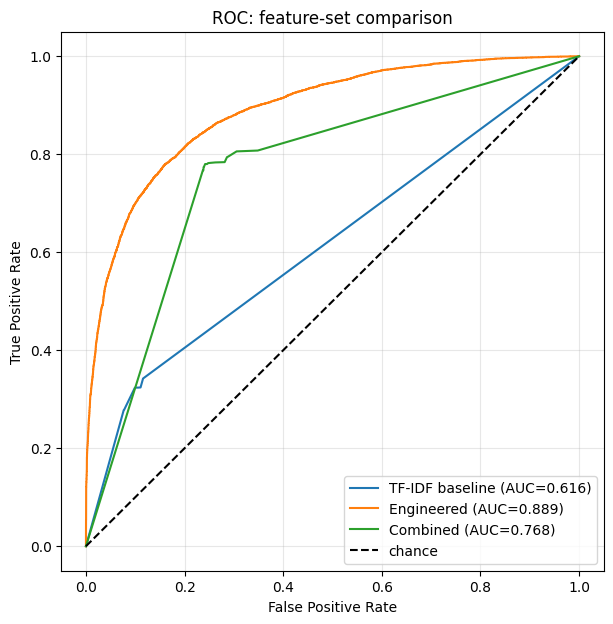

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 7))
for name, (Xtr, Xte) in {
    "TF-IDF baseline": (Xtrain_tfidf, Xtest_tfidf),
    "Engineered":      (Xtrain_eng,   Xtest_eng),
    "Combined":        (Xtrain_comb,  Xtest_comb),
}.items():
    m = make_model().fit(Xtr, y_train)
    scores = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, scores):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: feature-set comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()